In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report
import warnings
import joblib

warnings.filterwarnings('ignore')

# styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print(" All libraries imported successfully!")

 All libraries imported successfully!


READ the dataset


In [4]:
df = pd.read_csv("retail_sale_cleaned.csv")
print(f"Data Shape: {df.shape}")
df.head()

Data Shape: (50783, 16)


,id,timestamp,quantity,product_id,product_name,unit_price,total_amount,store,payment_method,customer_id,customer_type,year,month,day,day_name,hour
0,47d54138-a950-4ec0-9d4a-e637e8dfb290,2022-04-28 09:11:00,10,56b274d1-b2a4-47be-abaf-6c1c7742beb9,wheat,0.39,3.90,South Billyview,cash,c2b9eddd-df8c-446a-ae34-50ad88f28e0a,non-member,2022,4,28,Thursday,9
1,dea298b1-26ca-4a43-bcef-4050fb74ce1d,2019-12-06 16:21:00,1,56b274d1-b2a4-47be-abaf-6c1c7742beb9,wheat,0.39,0.39,South Edward,contactless,134a3c2c-8ccc-494c-9916-a15ff10a9125,member,2019,12,6,Friday,16
2,8dcd78f6-2e68-4fe3-9bb0-afe3bb2c3944,2019-06-22 15:27:00,10,56b274d1-b2a4-47be-abaf-6c1c7742beb9,wheat,0.39,3.90,South Billyview,contactless,a310b698-4e34-4a4a-8c60-e72fad63f9ba,gold,2019,6,22,Saturday,15
3,261c100c-b121-44b7-bc03-787f396c2061,2020-08-16 18:14:00,8,56b274d1-b2a4-47be-abaf-6c1c7742beb9,wheat,0.39,3.12,South Michaelfurt,credit card,0dfaced3-271c-4da0-80fc-fd3de4328bd5,corporate,2020,8,16,Sunday,18
4,7d025b4d-caac-40a5-b954-63cd7bd20f92,2019-11-12 15:46:00,1,56b274d1-b2a4-47be-abaf-6c1c7742beb9,wheat,0.39,0.39,Christopherfurt,cash,b05efb3f-c38e-4b86-8366-32e42340a4dc,gold,2019,11,12,Tuesday,15


In [5]:
df.columns

Index(['id', 'timestamp', 'quantity', 'product_id', 'product_name',
       'unit_price', 'total_amount', 'store', 'payment_method', 'customer_id',
       'customer_type', 'year', 'month', 'day', 'day_name', 'hour'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50783 entries, 0 to 50782
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              50783 non-null  object 
 1   timestamp       50783 non-null  object 
 2   quantity        50783 non-null  int64  
 3   product_id      50783 non-null  object 
 4   product_name    50783 non-null  object 
 5   unit_price      50783 non-null  float64
 6   total_amount    50783 non-null  float64
 7   store           50783 non-null  object 
 8   payment_method  50783 non-null  object 
 9   customer_id     50783 non-null  object 
 10  customer_type   50783 non-null  object 
 11  year            50783 non-null  int64  
 12  month           50783 non-null  int64  
 13  day             50783 non-null  int64  
 14  day_name        50783 non-null  object 
 15  hour            50783 non-null  int64  
dtypes: float64(2), int64(5), object(9)
memory usage: 6.2+ MB


In [7]:
df.describe()

,quantity,unit_price,total_amount,year,month,day,hour
count,50783.000000,50783.000000,50783.000000,50783.000000,50783.000000,50783.000000,50783.000000
mean,5.496485,2.641631,14.520505,2020.453439,6.546305,15.674222,13.994782
std,2.866948,1.409238,11.546789,0.954951,3.451267,8.790989,3.745102
min,1.000000,0.090000,0.090000,2019.000000,1.000000,1.000000,8.000000
25%,3.000000,1.490000,4.900000,2020.000000,4.000000,8.000000,11.000000
50%,5.000000,2.700000,11.400000,2020.000000,7.000000,16.000000,14.000000
75%,8.000000,3.900000,21.600000,2021.000000,10.000000,23.000000,17.000000
max,10.000000,4.990000,49.900000,2022.000000,12.000000,31.000000,20.000000


In [8]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nMissing Percentage:\n")
print((df.isnull().sum() / len(df)) * 100)

Missing Values:

id                0
timestamp         0
quantity          0
product_id        0
product_name      0
unit_price        0
total_amount      0
store             0
payment_method    0
customer_id       0
customer_type     0
year              0
month             0
day               0
day_name          0
hour              0
dtype: int64

Missing Percentage:

id                0.0
timestamp         0.0
quantity          0.0
product_id        0.0
product_name      0.0
unit_price        0.0
total_amount      0.0
store             0.0
payment_method    0.0
customer_id       0.0
customer_type     0.0
year              0.0
month             0.0
day               0.0
day_name          0.0
hour              0.0
dtype: float64


In [9]:
print("== Data Information ==")
print(df.info())
print("\n== Missing Values ==")
print(df.isnull().sum())

df['product_name'] = df['product_name'].fillna('Unknown')


print(" Missing Values handled!")

== Data Information ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50783 entries, 0 to 50782
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              50783 non-null  object 
 1   timestamp       50783 non-null  object 
 2   quantity        50783 non-null  int64  
 3   product_id      50783 non-null  object 
 4   product_name    50783 non-null  object 
 5   unit_price      50783 non-null  float64
 6   total_amount    50783 non-null  float64
 7   store           50783 non-null  object 
 8   payment_method  50783 non-null  object 
 9   customer_id     50783 non-null  object 
 10  customer_type   50783 non-null  object 
 11  year            50783 non-null  int64  
 12  month           50783 non-null  int64  
 13  day             50783 non-null  int64  
 14  day_name        50783 non-null  object 
 15  hour            50783 non-null  int64  
dtypes: float64(2), int64(5), object(9)
memory usage: 6.2+

In [10]:
print("Descriptive Statistics for Total Amount:")
print(df['total_amount'].describe())

Descriptive Statistics for Total Amount:
count    50783.000000
mean        14.520505
std         11.546789
min          0.090000
25%          4.900000
50%         11.400000
75%         21.600000
max         49.900000
Name: total_amount, dtype: float64


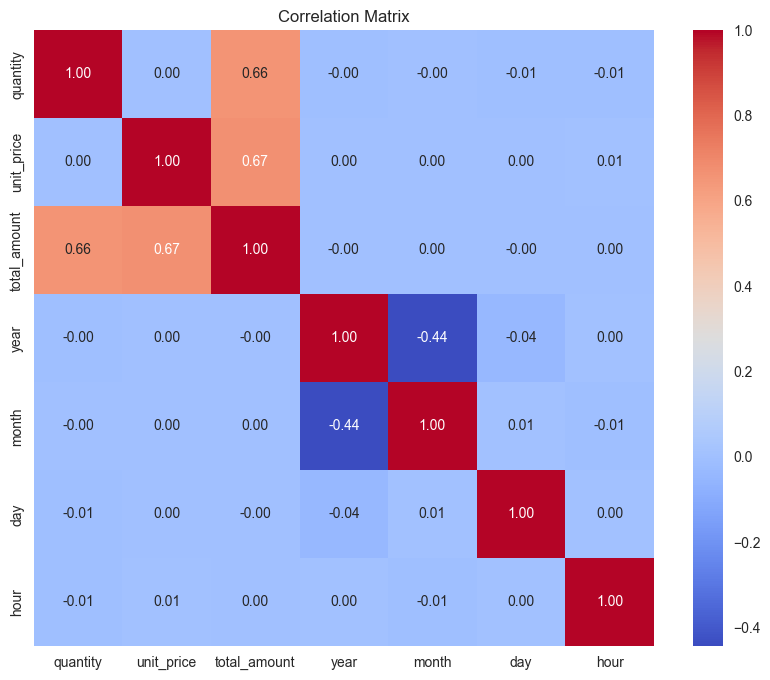

In [11]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [12]:
print("== 1. T-Test: Total Amount by Customer Type (Member vs Non-member) ==")
member = df[df['customer_type'] == 'member']['total_amount']
non_member = df[df['customer_type'] == 'non-member']['total_amount']
t_stat, p_val = ttest_ind(member, non_member, nan_policy='omit')
print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4f}")

print("\n== 2. ANOVA: Total Amount by Product Category (using product_name) ==")
groups = [group['total_amount'].values for name, group in df.groupby('product_name')]
f_stat, p_val = f_oneway(*groups[:5])  # limit to first 5 for speed
print(f"F-statistic: {f_stat:.4f}, P-value: {p_val:.4f}")

print("\n== 3. Chi-square Test: Payment Method vs Customer Type ==")
contingency = pd.crosstab(df['payment_method'], df['customer_type'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square: {chi2:.4f}, P-value: {p:.4f}")

== 1. T-Test: Total Amount by Customer Type (Member vs Non-member) ==
T-statistic: -0.2841, P-value: 0.7763

== 2. ANOVA: Total Amount by Product Category (using product_name) ==
F-statistic: 103.5739, P-value: 0.0000

== 3. Chi-square Test: Payment Method vs Customer Type ==
Chi-square: 11.0693, P-value: 0.7477


In [13]:

X = pd.get_dummies(df.drop(['id', 'timestamp', 'total_amount', 'customer_id', 'product_id'], axis=1, errors='ignore'), 
                   drop_first=True)
y = df['total_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

print("== Regression Result ==")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

joblib.dump(reg_model, 'retail_sales_regression_model.pkl')
print("Model saved as 'retail_sales_regression_model.pkl'")

== Regression Result ==
R² Score: 0.8730
RMSE: 4.08
Model saved as 'retail_sales_regression_model.pkl'


In [14]:
X = pd.get_dummies(df.drop(['id', 'timestamp', 'total_amount', 'customer_id', 'product_id'], axis=1, errors='ignore'), 
                   drop_first=True)
y = df['total_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

print("== Regression Result ==")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

joblib.dump(reg_model, 'retail_sales_regression_model.pkl')
print("Model saved as 'retail_sales_regression_model.pkl'")

== Regression Result ==
R² Score: 0.8730
RMSE: 4.08
Model saved as 'retail_sales_regression_model.pkl'


In [23]:
df['high_value'] = (df['total_amount'] > df['total_amount'].median()).astype(int)

X = pd.get_dummies(df.drop(['id', 'timestamp', 'total_amount', 'customer_id', 'product_id', 'high_value'], 
                           axis=1, errors='ignore'), drop_first=True)
y = df['high_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=y, random_state=42)

clf_model = RandomForestClassifier(n_estimators=80,max_depth=8,
                             min_samples_split=10,min_samples_leaf=5,
                             max_features='sqrt',bootstrap=True,random_state=42)
clf_model.fit(X_train, y_train)
y_pred = clf_model.predict(X_test)

print("=== Classification Results (High Value Purchase) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

joblib.dump(clf_model, 'high_value_classifier_model.pkl')
print(" Model saved as 'high_value_classifier_model.pkl'")

=== Classification Results (High Value Purchase) ===
Accuracy: 0.9107
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      7644
           1       0.91      0.91      0.91      7591

    accuracy                           0.91     15235
   macro avg       0.91      0.91      0.91     15235
weighted avg       0.91      0.91      0.91     15235

 Model saved as 'high_value_classifier_model.pkl'


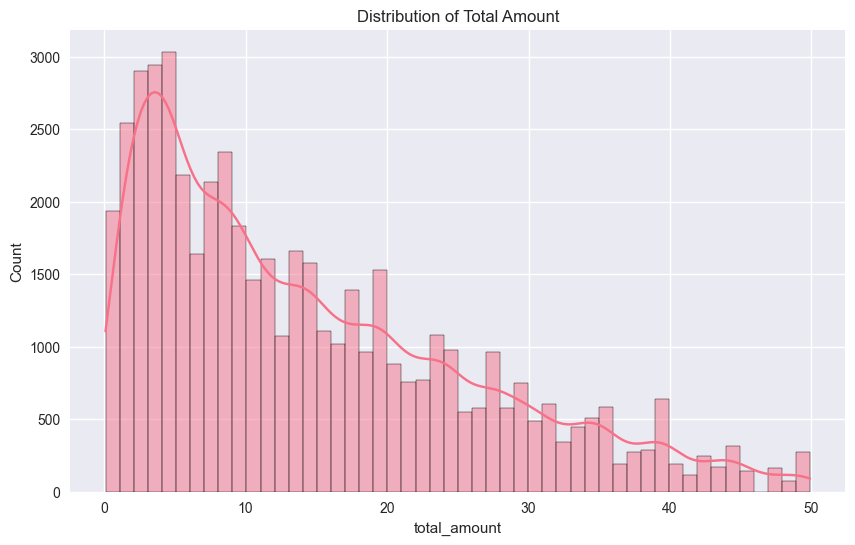

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(df['total_amount'], kde=True, bins=50)
plt.title('Distribution of Total Amount')
plt.show()

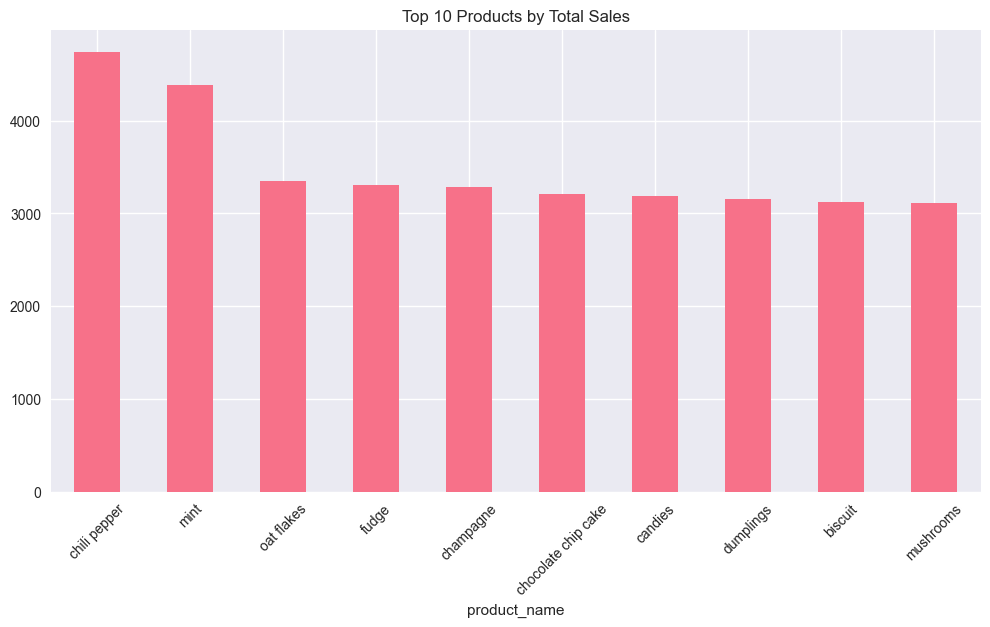

In [17]:
plt.figure(figsize=(12,6))
df.groupby('product_name')['total_amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Products by Total Sales')
plt.xticks(rotation=45)
plt.show()